In [1]:
pip install torch torchvision matplotlib numpy scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 86.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

Dispositivo utilizado: cpu


100%|██████████| 170M/170M [00:03<00:00, 47.5MB/s]



Visualizando muestras del dataset...


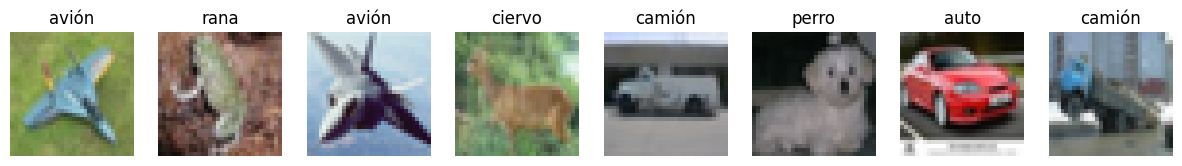


Arquitectura del modelo:
CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (relu): ReLU()
)

Comenzando entrenamiento...
Epoch [1/15] | Train Loss: 1.4643, Train Acc: 0.4738 | Val Loss: 1.1500, Val Acc: 0.5939
Epoch [2/15] | Train Loss: 1.1044, Train Acc: 0.6049 | Val Loss: 0.9788, Val Acc: 0.6492
Epoch [3/15] | Train Loss: 0.9508, Train Acc: 0.6624 | Val Loss: 0.8970, Val Acc: 0.6833
Epoch [4/15] | Train Loss: 0.8476, Train Acc: 0.6988 | Val Loss: 0.8689, Val Acc: 0.6919
Epoch [5/15] | Train Loss: 0.7574, Train Acc: 0.7311 | Val Loss: 0.8407, Val Acc: 0.7042
Epoch [6/15] | Train Loss: 0.6785, Train Acc: 0.7593 | Val Loss: 0.809

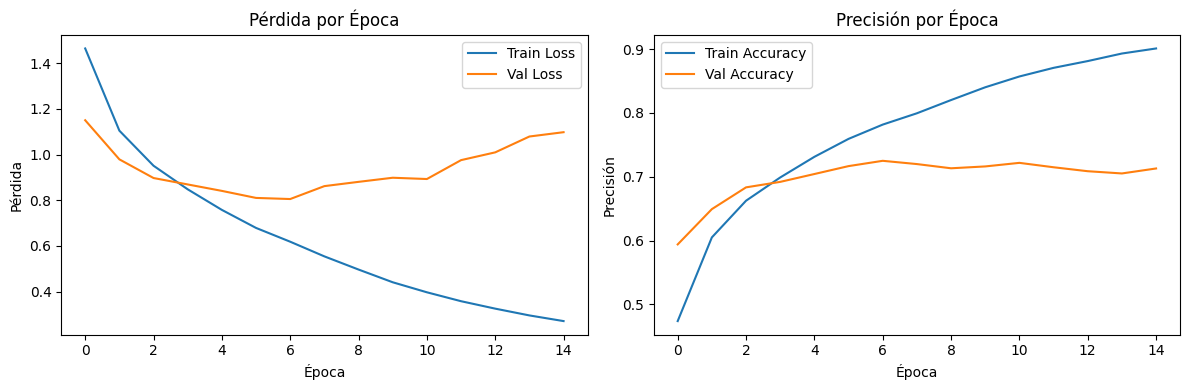


Evaluando en conjunto de prueba...
Precisión en test: 0.7125


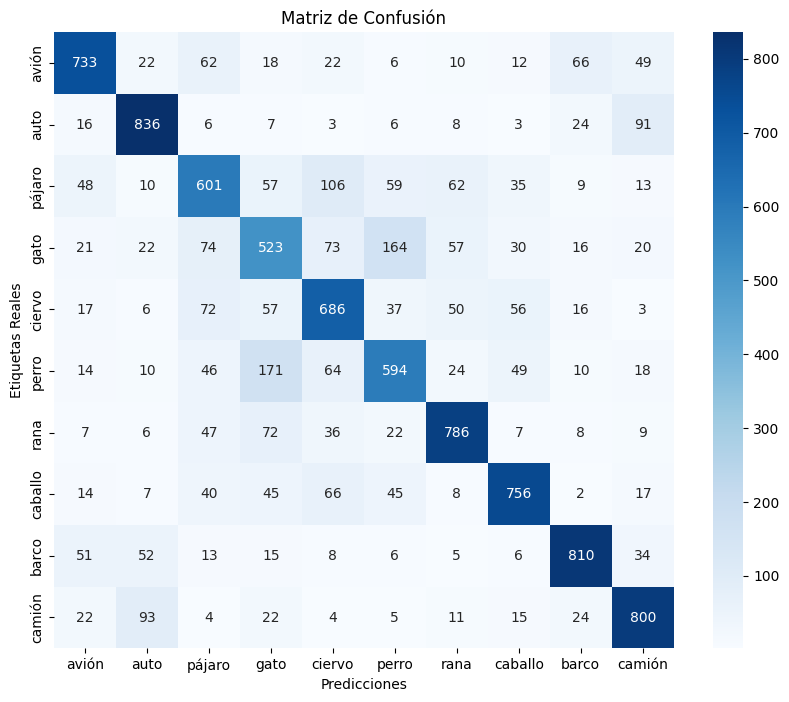


Reporte de Clasificación:
              precision    recall  f1-score   support

       avión       0.78      0.73      0.75      1000
        auto       0.79      0.84      0.81      1000
      pájaro       0.62      0.60      0.61      1000
        gato       0.53      0.52      0.53      1000
      ciervo       0.64      0.69      0.66      1000
       perro       0.63      0.59      0.61      1000
        rana       0.77      0.79      0.78      1000
     caballo       0.78      0.76      0.77      1000
       barco       0.82      0.81      0.82      1000
      camión       0.76      0.80      0.78      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000



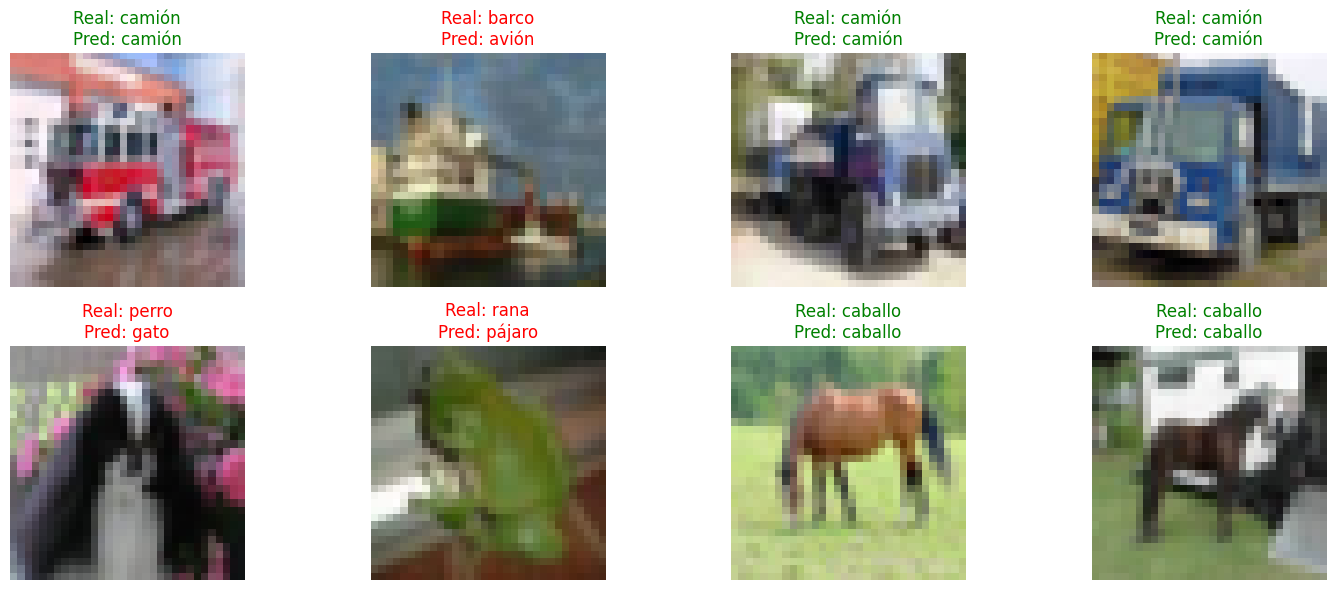


Modelo guardado como 'modelo_cifar10_cnn.pth'


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

# ------------------------------
# 1. Configuración inicial
# ------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo utilizado: {device}")

# Semilla para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# ------------------------------
# 2. Carga y preparación de datos
# ------------------------------
def load_data():
    """Carga y prepara el dataset CIFAR-10"""
    # Transformaciones para las imágenes
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # Descargar datos
    train_data = datasets.CIFAR10(
        root='data',
        train=True,
        download=True,
        transform=transform
    )

    test_data = datasets.CIFAR10(
        root='data',
        train=False,
        download=True,
        transform=transform
    )

    # Dividir entrenamiento en train/validation (80/20)
    train_size = int(0.8 * len(train_data))
    val_size = len(train_data) - train_size
    train_subset, val_subset = random_split(train_data, [train_size, val_size])

    # Crear DataLoaders
    batch_size = 64
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size)
    test_loader = DataLoader(test_data, batch_size=batch_size)

    return train_loader, val_loader, test_loader

# Clases de CIFAR-10
classes = ('avión', 'auto', 'pájaro', 'gato', 'ciervo',
           'perro', 'rana', 'caballo', 'barco', 'camión')

# ------------------------------
# 3. Visualización de datos
# ------------------------------
def visualize_samples(loader, num_samples=8):
    """Muestra muestras del dataset con sus etiquetas"""
    dataiter = iter(loader)
    images, labels = next(dataiter)

    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    for i in range(num_samples):
        # Desnormalizar la imagen
        img = images[i] / 2 + 0.5
        img = img.numpy().transpose((1, 2, 0))

        axes[i].imshow(img)
        axes[i].set_title(classes[labels[i]])
        axes[i].axis('off')
    plt.show()

# ------------------------------
# 4. Definición del modelo CNN
# ------------------------------
class CNN(nn.Module):
    """Modelo CNN para clasificación de imágenes"""
    def __init__(self):
        super(CNN, self).__init__()
        # Capas convolucionales
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # Capas de pooling
        self.pool = nn.MaxPool2d(2, 2)

        # Capas completamente conectadas
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

        # Dropout para regularización
        self.dropout = nn.Dropout(0.25)

        # Funciones de activación
        self.relu = nn.ReLU()

    def forward(self, x):
        # Bloque 1: Conv -> ReLU -> Pool
        x = self.pool(self.relu(self.conv1(x)))

        # Bloque 2: Conv -> ReLU -> Pool
        x = self.pool(self.relu(self.conv2(x)))

        # Aplanar para capas FC
        x = x.view(-1, 64 * 8 * 8)

        # Bloque FC: FC -> ReLU -> Dropout -> FC
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

# ------------------------------
# 5. Entrenamiento del modelo
# ------------------------------
def train_model(model, train_loader, val_loader, epochs=15):
    """Entrena el modelo y devuelve métricas de rendimiento"""
    # Configuración de entrenamiento
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Historial de métricas
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    start_time = time.time()

    for epoch in range(epochs):
        # Fase de entrenamiento
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Paso forward
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Paso backward y optimización
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Calcular métricas
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        # Calcular métricas de entrenamiento
        train_loss = train_loss / len(train_loader)
        train_acc = correct_train / total_train

        # Fase de validación
        val_loss, val_acc = evaluate_model(model, val_loader, criterion)

        # Guardar métricas
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # Mostrar progreso
        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Tiempo total de entrenamiento
    training_time = time.time() - start_time
    print(f"\nEntrenamiento completado en {training_time//60:.0f}m {training_time%60:.0f}s")

    return history

def evaluate_model(model, loader, criterion=None):
    """Evalúa el modelo en un conjunto de datos"""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            if criterion:
                loss = criterion(outputs, labels)
                total_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    loss = total_loss / len(loader) if criterion else None
    accuracy = correct / total

    return loss, accuracy

# ------------------------------
# 6. Visualización de resultados
# ------------------------------
def plot_metrics(history):
    """Grafica las métricas de entrenamiento y validación"""
    plt.figure(figsize=(12, 4))

    # Gráfico de pérdida
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Pérdida por Época')
    plt.xlabel('Época')
    plt.ylabel('Pérdida')
    plt.legend()

    # Gráfico de precisión
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Val Accuracy')
    plt.title('Precisión por Época')
    plt.xlabel('Época')
    plt.ylabel('Precisión')
    plt.legend()

    plt.tight_layout()
    plt.savefig('resultados/metricas_entrenamiento.png')
    plt.show()

def plot_confusion_matrix(model, loader):
    """Genera y muestra la matriz de confusión"""
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    # Crear matriz de confusión
    cm = confusion_matrix(all_labels, all_preds)

    # Visualizar
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicciones')
    plt.ylabel('Etiquetas Reales')
    plt.title('Matriz de Confusión')
    plt.savefig('resultados/matriz_confusion.png')
    plt.show()

    # Reporte de clasificación
    print("\nReporte de Clasificación:")
    print(classification_report(all_labels, all_preds, target_names=classes))

def visualize_predictions(model, loader, num_samples=8):
    """Visualiza predicciones correctas e incorrectas"""
    model.eval()
    dataiter = iter(loader)
    images, labels = next(dataiter)
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    # Seleccionar muestras aleatorias
    indices = np.random.choice(range(len(images)), num_samples)

    fig, axes = plt.subplots(2, num_samples//2, figsize=(15, 6))
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        img = images[idx].cpu() / 2 + 0.5
        img = img.numpy().transpose((1, 2, 0))

        axes[i].imshow(img)

        # Resaltar predicciones incorrectas en rojo
        color = 'green' if preds[idx] == labels[idx] else 'red'
        title = f"Real: {classes[labels[idx]]}\nPred: {classes[preds[idx]]}"
        axes[i].set_title(title, color=color)
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig('resultados/predicciones_ejemplo.png')
    plt.show()

# ------------------------------
# 7. Función principal
# ------------------------------
def main():
    # Crear carpeta para resultados
    import os
    os.makedirs('resultados', exist_ok=True)

    # 1. Cargar datos
    train_loader, val_loader, test_loader = load_data()

    # 2. Visualizar muestras
    print("\nVisualizando muestras del dataset...")
    visualize_samples(train_loader)

    # 3. Inicializar modelo
    model = CNN().to(device)
    print("\nArquitectura del modelo:")
    print(model)

    # 4. Entrenar modelo
    print("\nComenzando entrenamiento...")
    history = train_model(model, train_loader, val_loader, epochs=15)

    # 5. Visualizar métricas de entrenamiento
    print("\nVisualizando métricas...")
    plot_metrics(history)

    # 6. Evaluar en test set
    print("\nEvaluando en conjunto de prueba...")
    _, test_acc = evaluate_model(model, test_loader)
    print(f"Precisión en test: {test_acc:.4f}")

    # 7. Visualizar resultados
    plot_confusion_matrix(model, test_loader)
    visualize_predictions(model, test_loader)

    # 8. Guardar modelo
    torch.save(model.state_dict(), 'modelo_cifar10_cnn.pth')
    print("\nModelo guardado como 'modelo_cifar10_cnn.pth'")

if __name__ == "__main__":
    main()